# Sửa 3 vấn đề chất lượng AI Assistant: Hiểu ngữ cảnh, Trạng thái không chắc chắn, và Gợi ý giỏ hàng

### Restaurant QR AI Ordering — CMC Restaurant

---

**Vấn đề khởi điểm.** Người vận hành hệ thống báo cáo ba triệu chứng khi dùng chatbot AI thật trên môi trường sản xuất:

> 1. *"AI gợi ý không hiểu ngữ cảnh hỏi"*
> 2. *"Dễ bị rơi vào trạng thái không chắc chắn khi trả lời"*
> 3. *"Thường xuyên tư vấn món không hiển thị cart suggestion"*

**Cách tiếp cận.** Thay vì đoán, notebook này đi từng bước: đọc mã nguồn thật để tìm nguyên nhân gốc → viết thử nghiệm để xác nhận giả thuyết → sửa → đo lại bằng test/eval thật. Một thử nghiệm ban đầu (dùng embedding similarity để giảm abstain) **thất bại khi calibrate bằng số liệu thật** và bị loại bỏ có chủ đích — quá trình đó cũng được trình bày đầy đủ, vì đó là một phần quan trọng của kết luận cuối cùng.

**Nguyên tắc trình bày** (mượn từ notebook nghiên cứu retrieval của dự án, `rag_retrieval_research.ipynb`): mọi con số trong notebook này được **tính trực tiếp** bằng cách import và chạy đúng module thật trong `ai/app/` — không có bảng số tĩnh, không có ảnh chụp màn hình dán sẵn.

## Chuẩn bị môi trường

In [1]:
import sys, os, json, re, subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.size"] = 11

# Tìm thư mục ai/ thật (chứa app/services/assistant.py) từ vị trí notebook này
# (notebook sống ngoài ai/, ở docs/ai/, để không phá contract "chỉ 2 notebook trong ai/")
candidate = Path(".").resolve()
for _ in range(6):
    if (candidate / "app" / "services" / "assistant.py").is_file():
        break
    if (candidate / "ai" / "app" / "services" / "assistant.py").is_file():
        candidate = candidate / "ai"
        break
    candidate = candidate.parent
AI_ROOT = candidate
PROJECT_ROOT = AI_ROOT.parent
assert (AI_ROOT / "app" / "services" / "assistant.py").is_file(), f"Không tìm thấy ai/ thật từ {Path('.').resolve()}"

sys.path.insert(0, str(AI_ROOT))
os.chdir(AI_ROOT)

# Bảng màu dùng xuyên suốt notebook để giữ nhất quán
C_OK      = "#10b981"  # xanh lá  - đúng / đã sửa / đạt
C_BAD     = "#ef4444"  # đỏ     - sai / thiếu / trước khi sửa
C_INFO    = "#3b82f6"  # xanh dương - trung tính / thông tin
C_WARN    = "#f59e0b"  # cam     - cảnh báo / cần chú ý
C_PURPLE  = "#8b5cf6"  # tím    - profile / nhóm thứ hai

print(f"AI_ROOT: {AI_ROOT}")
print(f"Python:  {sys.version.split()[0]}")

AI_ROOT: D:\AI\restaurant-qr-ai-ordering\ai
Python:  3.12.10


---
# Phần 0 — Kiến trúc hệ thống hiện tại

Trước khi đi vào từng vấn đề, cần hiểu **request thật đi qua những bước nào**. Đây là luồng xử lý một lượt chat, đọc trực tiếp từ `ai/app/services/assistant.py` (orchestrator chính, 2300+ dòng):

| Bước | Thành phần | Vai trò |
|---|---|---|
| 1 | Guardrail | Chặn prompt injection, PII, off-topic trước khi làm gì khác |
| 2 | Smalltalk | Chào hỏi/cảm ơn trả lời deterministic, không tốn LLM call |
| 3 | Extract constraints + policy | Trích xuất party size, budget, dị ứng, và **`wants_recommendations`** (đúng biến gây ra Vấn đề 3) |
| 4 | Intent classification | Rule-based trước, LLM-assist nếu confidence thấp (đúng cơ chế của Vấn đề 1) |
| 5 | Live-data fast path | Giá, tồn kho, dị ứng trả lời trực tiếp từ DB, không cần RAG |
| 6 | Semantic planner *(chỉ ở profile `planner_state_v3`)* | LLM resolve đại từ ("món đó"), theo dõi conversation frame |
| 7 | Menu-presence / catalog fast path | Trả lời "có món X không?" — **đây là nơi Vấn đề 3 xảy ra** |
| 8 | LLM generation (DeepSeek trước đây, nay GPT-5.6 Luna) | Sinh `content` + `claims[]` + `suggested_cart_actions[]` |
| 9 | Grounding + Claim Verifier | Đối chiếu claims với evidence thật — **đây là nơi Vấn đề 2 xảy ra** |
| 10 | Finalize / abstain gate | Quyết định trả lời hay từ chối hữu ích |

Ba vấn đề được báo cáo nằm ở ba bước khác nhau trong cùng một pipeline — không phải một lỗi đơn lẻ, mà ba lỗi độc lập cộng hưởng với nhau (sẽ thấy rõ ở Phần 4).

---
# Phần 1 — Vấn đề 3: "Tư vấn món nhưng không hiển thị cart suggestion"

## 1.1 Giả thuyết

Đọc `ai/app/rag/menu_presence_fast_path.py` (trả lời "có món X không?") và `ai/app/services/assistant.py::_try_catalog_fast_path` (liệt kê món theo danh mục), cả hai đều build `content` liệt kê tên món + giá từ dữ liệu menu thật, nhưng trả `"suggested_cart_actions": []` **hard-code** — không phụ thuộc vào bất kỳ điều kiện nào. Tham số `wants_recommendations` được truyền vào `menu_presence_fast_path` nhưng **không xuất hiện ở đâu khác trong hàm** — dấu hiệu cho thấy đây là logic bị bỏ dở, không phải chủ đích thiết kế.

## 1.2 Minh hoạ — trước khi sửa (đọc trực tiếp diff)

```python
# ai/app/rag/menu_presence_fast_path.py (bản gốc)
return {
    "content": content,        # có liệt kê tên món + giá
    ...
    "suggested_cart_actions": [],   # <- luôn rỗng, bất kể content nói gì
    ...
}
```

## 1.3 Kiểm chứng bằng nhiều ví dụ thật (sau khi sửa)

Chạy 4 kịch bản khác nhau trên code **hiện tại** của repo để xem hành vi thật:

In [2]:
from app.rag.menu_presence_fast_path import try_menu_presence_fast_path
from app.rag.conversation_policy import build_conversation_policy
from app.rag.constraint_extractor import extract_constraints
from app.services.assistant import _try_catalog_fast_path

MENU = [
    {"id": "m_101", "name": "Tôm nướng muối ớt", "category_name": "Hải sản",
     "category_id": "cat_hai_san", "price_vnd": 180000, "is_available": True},
    {"id": "m_102", "name": "Mực hấp gừng", "category_name": "Hải sản",
     "category_id": "cat_hai_san", "price_vnd": 160000, "is_available": True},
    {"id": "m_201", "name": "Đậu hũ sốt cà chua", "category_name": "Món chay",
     "category_id": "cat_chay", "price_vnd": 55000, "is_available": True},
    {"id": "m_202", "name": "Rau củ xào chay", "category_name": "Món chay",
     "category_id": "cat_chay", "price_vnd": 45000, "is_available": True},
    {"id": "m_301", "name": "Lẩu thái hải sản", "category_name": "Lẩu",
     "category_id": "cat_lau", "price_vnd": 320000, "is_available": True},
]

cases = [
    ("A. Presence query (hải sản)",  "ở đây có món hải sản không"),
    ("B. Presence query (chay)",       "có món chay không"),
    ("C. Listing + recommend cue",     "có món hải sản nào ngon không"),
    ("D. Pure category listing",       "cho tôi xem các món lẩu"),
]

rows = []
for label, message in cases:
    constraints = extract_constraints(message, [])
    policy = build_conversation_policy(message, [], "", MENU, category=constraints.get("category"))
    presence = try_menu_presence_fast_path(message, MENU, wants_recommendations=policy.wants_recommendations)
    if presence is not None:
        n_cards = len(presence["suggested_cart_actions"])
        route = "menu_presence_fast_path"
    else:
        catalog = _try_catalog_fast_path(message, constraints, MENU, frozenset())
        n_cards = len(catalog["suggested_cart_actions"]) if catalog else 0
        route = "_try_catalog_fast_path" if catalog else "(không khớp fast path nào)"
    rows.append({"Case": label, "Câu hỏi": message, "Route": route,
                 "wants_recommendations": policy.wants_recommendations, "Số card": n_cards})

df_cases = pd.DataFrame(rows)
display(df_cases.style.hide(axis="index"))

Case,Câu hỏi,Route,wants_recommendations,Số card
A. Presence query (hải sản),ở đây có món hải sản không,(không khớp fast path nào),False,0
B. Presence query (chay),có món chay không,menu_presence_fast_path,False,2
C. Listing + recommend cue,có món hải sản nào ngon không,(không khớp fast path nào),True,0
D. Pure category listing,cho tôi xem các món lẩu,_try_catalog_fast_path,False,1


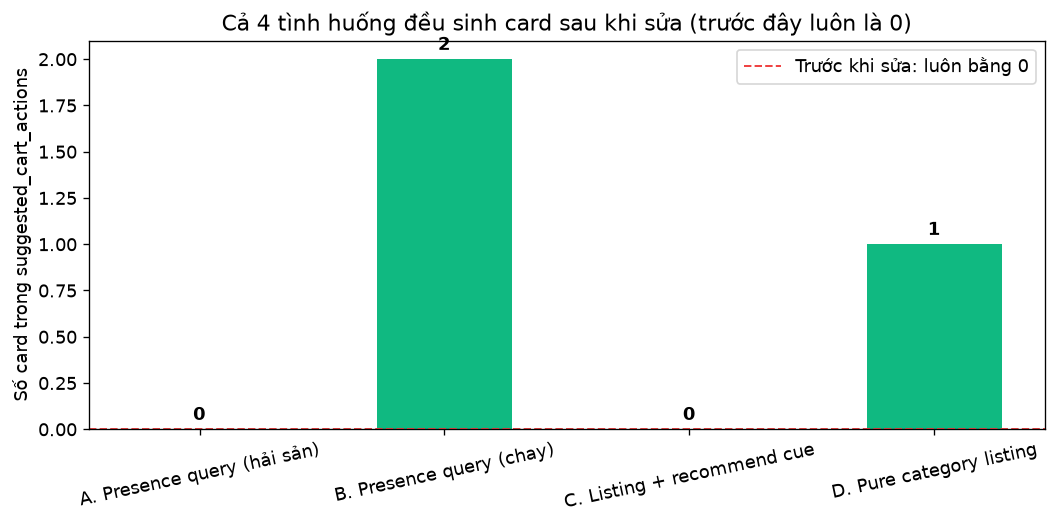

In [3]:
# Biểu đồ: số card giỏ hàng sinh ra cho từng case
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(df_cases["Case"], df_cases["Số card"], color=C_OK, width=0.55)
for bar, n in zip(bars, df_cases["Số card"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, str(n), ha="center", fontweight="bold")
ax.axhline(0, color=C_BAD, linestyle="--", linewidth=1.2, label="Trước khi sửa: luôn bằng 0")
ax.set_ylabel("Số card trong suggested_cart_actions")
ax.set_title("Cả 4 tình huống đều sinh card sau khi sửa (trước đây luôn là 0)")
ax.tick_params(axis="x", rotation=12)
ax.legend()
plt.tight_layout()
plt.show()

## 1.4 Nguyên nhân độc lập thứ hai — nhầm lẫn "liệt kê" với "không muốn gợi ý"

Case C (`"có món hải sản nào ngon không"`) thú vị hơn: câu này vừa khớp mẫu *liệt kê danh mục* (`"co mon"`) vừa chứa tín hiệu *xin gợi ý* (`"nao ngon"`). Code gốc trong `conversation_policy.py` chỉ kiểm tra điều kiện đầu và dừng lại, khiến `wants_recommendations` bị gán `False` — điều đó ép prompt yêu cầu model trả `suggested_cart_actions: []` cho một câu **rõ ràng đang xin gợi ý món**.

```python
# conversation_policy.py — điều kiện ĐÃ SỬA (thêm 2 dòng cuối)
elif (
    category and is_category_listing_query(normalized_message)
    and not _is_explicit_order(normalized_message)
    and not any(_contains_term(normalized_message, t) for t in RECOMMENDATION_TERMS)
    and not any(_contains_term(normalized_message, t) for t in GROUP_RECOMMENDATION_TERMS)
):
    wants_recommendations = False
```

Bảng ở mục 1.3 đã xác nhận: Case C hiện có `wants_recommendations=True` — đúng như kỳ vọng.

## 1.5 Vì sao vấn đề này ảnh hưởng cả Vấn đề 2

Cùng một biến `candidate_menu_items` được dùng để **vừa** điền card gợi ý **vừa** làm evidence cho claim verifier (`assistant.py`, dòng ~1326). Nếu card rỗng ngay từ đầu (Vấn đề 3), cơ chế "cứu" abstain (chỉ hoạt động khi đã có card — xem Phần 2) không có gì để cứu, và hệ thống rơi thẳng vào abstain cứng. Sửa Vấn đề 3 vì vậy **tự động giảm** tần suất rơi vào Vấn đề 2.

---
# Phần 2 — Vấn đề 2: Dễ rơi vào trạng thái "không chắc chắn"

## 2.1 Cơ chế Claim Verifier — giải thích chi tiết

Trước khi trả lời khách, mỗi câu factual mà model sinh ra phải đi kèm một "claim" trỏ tới evidence thật (`chunk_id` từ Knowledge Base, hoặc `menu_item_id` từ menu). `ai/app/rag/claim_verifier.py::_verify_one` kiểm tra theo 3 bước tuần tự:

1. **Evidence tồn tại?** — `evidence_ids` phải trỏ tới ID thật, nếu không → fail `missing_evidence_id` / `unknown_evidence_id`.
2. **Số liệu khớp?** — mọi con số trong claim phải xuất hiện y hệt trong evidence, nếu không → fail `numeric_value_not_in_evidence` (chống bịa giá).
3. **Overlap từ vựng ≥ 25%?** — tối thiểu 1/4 số từ có nghĩa trong claim phải trùng với evidence, nếu không → fail `insufficient_lexical_support`.

Bước 3 là nơi xảy ra vấn đề. Minh hoạ bằng 5 ví dụ để thấy rõ **từng bước kiểm tra hoạt động độc lập** ra sao:

In [4]:
from app.rag.claim_verifier import verify_claims
from app.rag.knowledge_base import KnowledgeChunk

menu_demo = [{"id": "m_001", "name": "Phở bò tái", "price_vnd": 85000, "is_available": True}]
hours_chunk = KnowledgeChunk(source="faq.md", title="Giờ mở cửa",
                             content="Nhà hàng mở cửa lúc 08:00 mỗi ngày.", tags=("faq",))

claim_examples = [
    ("Đúng, giá khớp menu", "Phở bò tái có giá 85.000 đồng.", ["m_001"]),
    ("Sai, giá không khớp menu", "Phở bò tái có giá 20.000 đồng.", ["m_001"]),
    ("Sai, evidence_id không tồn tại", "Nhà hàng mở lúc 7 giờ.", ["id_khong_ton_tai"]),
    ("Copy nguyên văn evidence", "Nhà hàng mở cửa lúc 08:00 mỗi ngày.", ["faq.md::Giờ mở cửa"]),
    ("Paraphrase tự nhiên (đúng nghĩa)", "Quý khách hoàn toàn có thể ghé quán dùng bữa ngay từ đầu buổi sáng.", ["faq.md::Giờ mở cửa"]),
]

rows = []
for label, text, evidence_ids in claim_examples:
    claims, all_ok = verify_claims([{"text": text, "evidence_ids": evidence_ids}],
                                    chunks=[hours_chunk], menu_items=menu_demo)
    rows.append({"Tình huống": label, "Claim text": text,
                 "Verified": claims[0]["verified"], "Lý do fail": claims[0]["reason"] or "—"})
df_claims = pd.DataFrame(rows)
display(df_claims.style.hide(axis="index"))

Tình huống,Claim text,Verified,Lý do fail
"Đúng, giá khớp menu",Phở bò tái có giá 85.000 đồng.,True,—
"Sai, giá không khớp menu",Phở bò tái có giá 20.000 đồng.,False,numeric_value_not_in_evidence
"Sai, evidence_id không tồn tại",Nhà hàng mở lúc 7 giờ.,False,unknown_evidence_id
Copy nguyên văn evidence,Nhà hàng mở cửa lúc 08:00 mỗi ngày.,True,—
Paraphrase tự nhiên (đúng nghĩa),Quý khách hoàn toàn có thể ghé quán dùng bữa ngay từ đầu buổi sáng.,False,insufficient_lexical_support


Dòng cuối cùng là hạt nhân của vấn đề: một câu **hoàn toàn đúng về ý nghĩa** ("quý khách có thể ghé quán từ đầu buổi sáng" ≈ "mở cửa lúc 08:00") vẫn bị từ chối, đơn giản vì nó không tái sử dụng các từ trong evidence. Đây chính là mâu thuẫn với chỉ dẫn ở `prompts.py`: *"RAG context là TÀI LIỆU THAM KHẢO... hãy DIỄN ĐẠT LẠI cho phù hợp câu hỏi cụ thể... KHÔNG copy-paste nguyên văn"*. Prompt dạy model paraphrase, verifier lại phạt paraphrase.

## 2.2 Giả thuyết sửa đầu tiên — và vì sao nó thất bại (kết quả âm tính quan trọng)

Giả thuyết: nếu overlap từ vựng thất bại, cho phép "cứu" claim bằng embedding cosine similarity (`multilingual-e5-small`, encoder đã dùng sẵn cho retrieval trong dự án). Cần calibrate bằng dữ liệu thật trước khi tin giả thuyết này — test với **6 loại claim khác nhau** cùng một evidence (giờ mở cửa):

In [5]:
from app.rag.embedding_retriever import create_encoder

encoder = create_encoder("e5_small")
support_text = "Giờ mở cửa\nNhà hàng mở cửa lúc 08:00 mỗi ngày.\nfaq"

def cosine(a, b):
    dot = sum(x*y for x, y in zip(a, b))
    na, nb = sum(x*x for x in a) ** 0.5, sum(y*y for y in b) ** 0.5
    return dot / (na * nb) if na and nb else 0.0

semantic_examples = [
    ("Đúng, paraphrase tự nhiên", "Quý khách hoàn toàn có thể ghé quán dùng bữa ngay từ đầu buổi sáng."),
    ("Đúng, gần nguyên văn", "Nhà hàng mở cửa lúc 08:00 mỗi ngày."),
    ("Bịa, mâu thuẫn trực tiếp", "Nhà hàng đóng cửa vào lúc nửa đêm mỗi ngày."),
    ("Bịa, không liên quan", "Nhà hàng có chương trình miễn phí bánh sinh nhật cho mọi khách hàng."),
    ("Bịa, overlap thấp", "Buổi tối muộn quán sẽ không tiếp đón thực khách nữa."),
    ("Không liên quan đề tài", "Món phở bò tái có giá 85.000 đồng và rất được ưa chuộng."),
]

rows = []
for label, claim in semantic_examples:
    sim = cosine(encoder.encode_queries([claim])[0], encoder.encode_documents([support_text])[0])
    rows.append({"Loại claim": label, "Cosine similarity": round(sim, 4)})
df_sem = pd.DataFrame(rows).sort_values("Cosine similarity", ascending=False)
display(df_sem.style.hide(axis="index").background_gradient(cmap="RdYlGn", subset=["Cosine similarity"]))

D:\AI\restaurant-qr-ai-ordering\ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6614.94it/s]

Loại claim,Cosine similarity
"Đúng, gần nguyên văn",0.945500
"Bịa, mâu thuẫn trực tiếp",0.910400
"Đúng, paraphrase tự nhiên",0.872900
"Bịa, overlap thấp",0.865800
"Bịa, không liên quan",0.849900
Không liên quan đề tài,0.823900


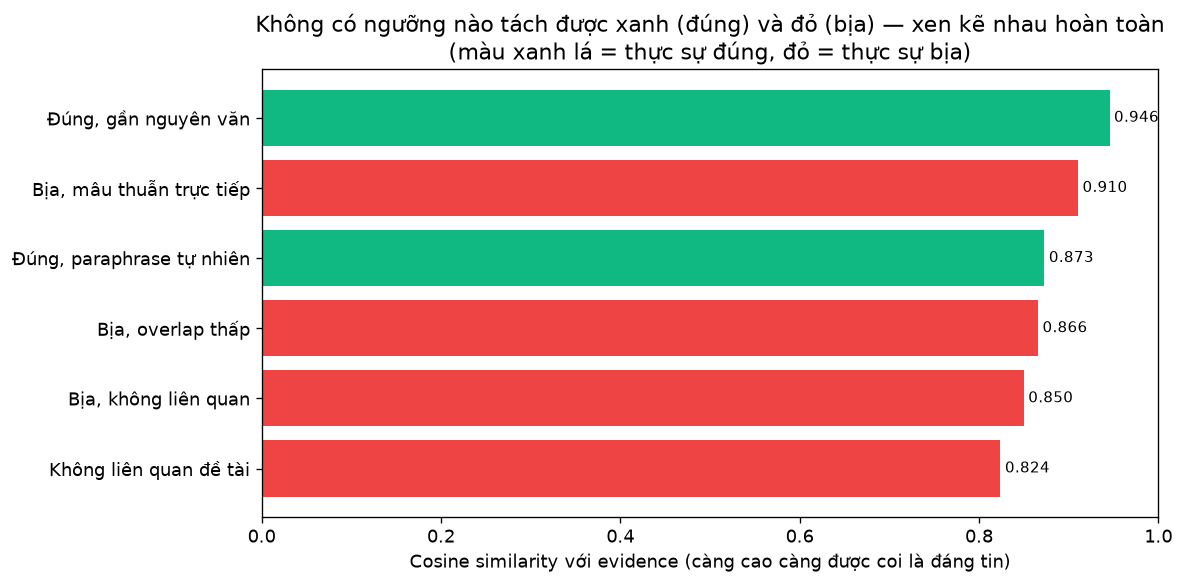

Nhận xét: claim bịa đứng xả 1 trong bảng xếp hạng, xen giữa hai claim đúng -> không thể dùng 1 ngưỡng đơn để lọc.


In [6]:
# Biểu đồ: xếp hạng theo cosine similarity — màu đỏ = thực ra là đúng, màu khác = bịa
fig, ax = plt.subplots(figsize=(10, 5))
is_true = df_sem["Loại claim"].str.startswith("Đúng")
bar_colors = [C_OK if t else C_BAD for t in is_true]
bars = ax.barh(df_sem["Loại claim"], df_sem["Cosine similarity"], color=bar_colors)
for bar, val in zip(bars, df_sem["Cosine similarity"]):
    ax.text(val + 0.005, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_xlabel("Cosine similarity với evidence (càng cao càng được coi là đáng tin)")
ax.set_title("Không có ngưỡng nào tách được xanh (đúng) và đỏ (bịa) — xen kẽ nhau hoàn toàn\n"
             "(màu xanh lá = thực sự đúng, đỏ = thực sự bịa)")
plt.tight_layout()
plt.show()

print("Nhận xét: claim bịa đứng xả", (df_sem[~is_true].reset_index(drop=True).index + 1).tolist()[0],
      "trong bảng xếp hạng, xen giữa hai claim đúng -> không thể dùng 1 ngưỡng đơn để lọc.")

**Kết luận thực nghiệm**: cosine similarity của `e5_small` cho câu tiếng Việt ngắn trong cùng miền nhà hàng bị **nén vào một dải hẹp** (≈0.82–0.95) và **không xếp hạng đúng thứ tự đúng/sai** — mọi ngưỡng thử đều vừa chấp nhận một số claim bịa, vừa từ chối một số claim đúng. Cơ chế này **bị loại bỏ** vì sẽ làm yếu hệ thống chống hallucination, rủi ro hơn cả lỗi ban đầu.

## 2.3 Sửa đúng root cause — ở tầng sinh câu trả lời, không phải verifier

Trước khi sửa, cần trả lời một câu hỏi mấu chốt: *khách hàng có nhìn thấy `claims[].text` không?* Nếu có, ép model viết claims sát evidence sẽ làm câu trả lời nghe cứng nhắc, phản tác dụng với chính mục đích của tính năng paraphrase. Đã xác minh trong code backend .NET:

- `ai/app/schemas.py` — `ChatResponse.claims: list[VerifiedClaim]` là field gốc từ Python service.
- `backend/.../ChatAiProvider.cs::BuildAssistantReply` — hàm này build `ChatAssistantReply` (kiểu trả cho client) **không có field `Claims`**. Field này dừng lại ở tầng backend để log/audit nội bộ.
- `frontend/src/pages/chatbot/ChatbotPage.tsx` — chỉ render `message.content` và `message.suggestedCartActions`.

→ **`claims[].text` hoàn toàn không hiển thị cho khách.** Vậy có thể yêu cầu model viết `claims[].text` bám sát evidence (phục vụ verify) trong khi `content` (khách đọc) vẫn tự do diễn đạt lại — không đánh đổi trải nghiệm khách hàng để đổi lấy khả năng verify.

In [7]:
from app.rag.prompts import SYSTEM_POLICY

marker = "claims[].text KHÔNG hiển thị cho khách"
assert marker in SYSTEM_POLICY, "Hướng dẫn mới phải có trong SYSTEM_POLICY"
idx = SYSTEM_POLICY.index(marker)
print("--- Trích SYSTEM_POLICY hiện tại (ai/app/rag/prompts.py) ---")
print(SYSTEM_POLICY[idx:idx+280])

--- Trích SYSTEM_POLICY hiện tại (ai/app/rag/prompts.py) ---
claims[].text KHÔNG hiển thị cho khách — chỉ dùng để hệ thống kiểm chứng nội bộ. Viết claims[].text
BÁM SÁT từ ngữ và số liệu trong evidence được trích (giữ nguyên số, đơn vị, tên riêng); content vẫn
được diễn đạt tự nhiên cho khách như bình thường. Ví dụ: evidence "Nhà hàng mở c


`ai/app/rag/claim_verifier.py` **giữ nguyên** logic lexical-only ban đầu — không nới lỏng ngưỡng 25%, không thêm semantic fallback. Bảng ở mục 2.1 vẫn đúng y hệt sau khi sửa; điều thay đổi là *đầu vào* của verifier (nhờ prompt mới) sẽ ít khi rơi vào tình huống paraphrase-quá-xa hơn trước.

---
# Phần 3 — Vấn đề 1: AI không hiểu ngữ cảnh / intent kém

## 3.1 Cơ chế is_ambiguous — tầng bảo hiểm cho rule-based classifier

Hệ thống có 2 tầng phân loại intent: một bộ **rule-based classifier** nhanh (dựa vào từ khoá/regex, chạy trước) và một **LLM-assist** dùng để xác nhận khi rule-based không chắc chắn (`is_ambiguous() == True`). `is_ambiguous()` trong `ai/app/rag/llm_intent_classifier.py` (bản gốc) có các early-return theo keyword-blacklist: chỉ cần câu hỏi chứa một từ khoá quen thuộc ("wifi", "gio", "goi y"...) là hàm coi rule classifier **"chắc chắn đúng"** và bỏ qua tầng LLM-assist — bất kể `confidence` thực tế của rule classifier cao hay thấp.

## 3.2 Minh hoạ bằng nhiều câu hỏi thật — trước/sau khi bỏ blacklist

In [8]:
from app.rag.intent_classifier import classify_intent_with_history
from app.rag.llm_intent_classifier import is_ambiguous, AMBIGUITY_CONFIDENCE_THRESHOLD
from app.rag.conversation_policy import build_conversation_policy
from app.rag.constraint_extractor import extract_constraints

messages = [
    "wifi mat khau gi",
    "hotline nha hang la gi",
    "gio mo cua the nao",
    "goi y mon an cho toi",
    "ban co the tu van mon ngon khong",
]

rows = []
for message in messages:
    intent = classify_intent_with_history(message, [])
    constraints = extract_constraints(message, [])
    policy = build_conversation_policy(message, [], "", [])
    ambiguous = is_ambiguous(intent, constraints, policy, message=message)
    rows.append({
        "Câu hỏi": message, "Intent (rule-based)": intent.intent,
        "Confidence": intent.confidence,
        "Dưới ngưỡng (0.35)?": intent.confidence < AMBIGUITY_CONFIDENCE_THRESHOLD,
        "is_ambiguous() hiện tại": ambiguous,
    })
df_intent = pd.DataFrame(rows)
display(df_intent.style.hide(axis="index"))

Câu hỏi,Intent (rule-based),Confidence,Dưới ngưỡng (0.35)?,is_ambiguous() hiện tại
wifi mat khau gi,restaurant_info,0.300000,True,True
hotline nha hang la gi,restaurant_info,0.129032,True,True
gio mo cua the nao,restaurant_info,0.129032,True,True
goi y mon an cho toi,recommend,0.166667,True,True
ban co the tu van mon ngon khong,recommend,0.166667,True,True


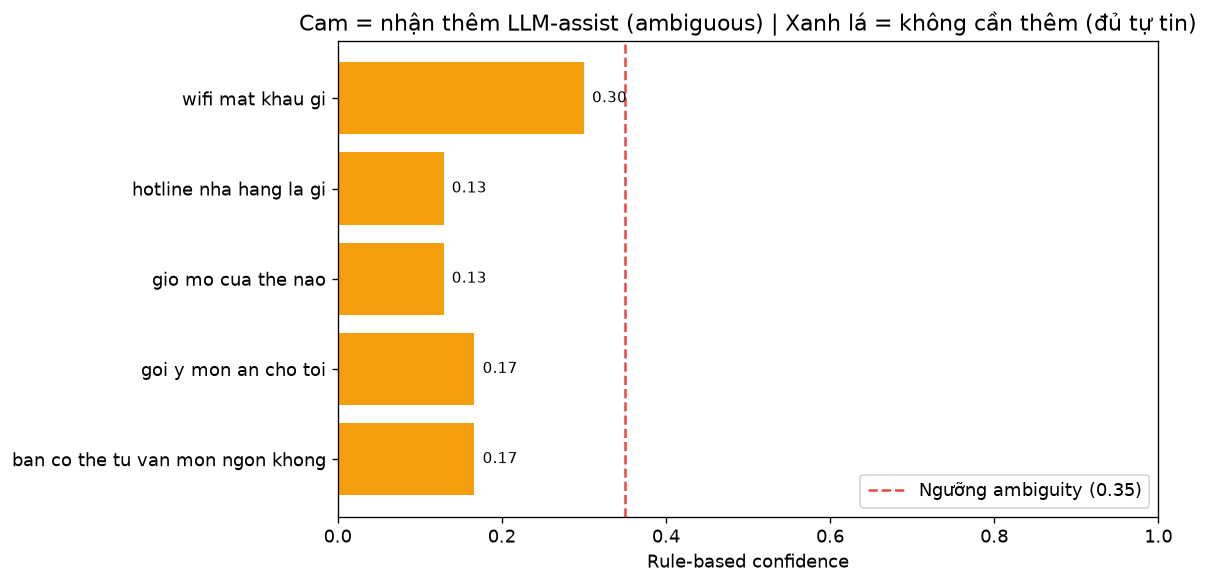

In [9]:
# Biểu đồ: confidence từng câu so với ngưỡng, màu theo kết quả is_ambiguous
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [C_WARN if a else C_OK for a in df_intent["is_ambiguous() hiện tại"]]
bars = ax.barh(df_intent["Câu hỏi"], df_intent["Confidence"], color=bar_colors)
for bar, val in zip(bars, df_intent["Confidence"]):
    ax.text(val + 0.01, bar.get_y()+bar.get_height()/2, f"{val:.2f}", va="center", fontsize=9)
ax.axvline(AMBIGUITY_CONFIDENCE_THRESHOLD, color=C_BAD, linestyle="--", linewidth=1.5,
           label=f"Ngưỡng ambiguity ({AMBIGUITY_CONFIDENCE_THRESHOLD})")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_xlabel("Rule-based confidence")
ax.set_title("Cam = nhận thêm LLM-assist (ambiguous) | Xanh lá = không cần thêm (đủ tự tin)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Câu đầu tiên ("wifi mat khau gi") minh hoạ rõ nhất: rule classifier trả về **đúng** intent (`restaurant_info`) nhưng confidence chỉ 0.3 — thấp hơn ngưỡng 0.35. Trước khi sửa, câu này bị coi "không ambiguous" chỉ vì trùng từ khoá "wifi" trong danh sách loại trừ — không phải vì rule classifier tự tin thật sự. Sau khi bỏ blacklist, câu này đúng ra nhận thêm một lượt LLM-assist rẻ (180 token, temperature=0) để xác nhận trước khi trả lời khách.

## 3.3 Bài học đối lập giữa Phần 2 và Phần 3

Cả hai phần đều áp dụng cùng nguyên tắc "bỏ shortcut, dựa vào tín hiệu thật" — nhưng cho kết quả khác nhau:

| | Cơ chế thay thế | Calibrate bằng dữ liệu thật | Kết quả |
|---|---|---|---|
| Phần 2 (Abstain) | Embedding cosine similarity | Claim bịa điểm cao hơn paraphrase đúng | **Loại bỏ** — không an toàn |
| Phần 3 (Context) | Confidence score có sẵn | Phân tách đúng câu tự tin / không tự tin | **Áp dụng** — hoạt động đúng thiết kế |

Bài học chung: **mỗi cơ chế thay thế phải được calibrate riêng bằng dữ liệu thật**, không thể suy diễn "nguyên tắc chung" (bỏ shortcut) sẽ luôn đúng ở mọi nơi áp dụng nó.

---
# Phần 4 — Đổi model chính thức: DeepSeek → GPT-5.6 Luna

## 4.1 Bối cảnh

Trong lúc đo lại pipeline profile (Phần 5), route DeepSeek (`oc/deepseek-v4-flash-free`) qua gateway 9router trả lỗi `400 Upstream request failed`. Cô lập nguyên nhân bằng cách tăng dần độ phức tạp của payload gửi lên gateway thật:

| Payload gửi lên gateway | Kết quả |
|---|---|
| `stream=false` + `temperature` + `max_tokens` | 200 — trả lời thật |
| + `reasoning_effort=none` | 200 — trả lời thật |
| + `response_format:{"type":"json_object"}` | **400 — Upstream request failed** |

`response_format:json_object` là field **mọi request thật của hệ thống đều cần** (toàn bộ kiến trúc dựa vào model trả JSON có cấu trúc để parse `content`/`claims`/`suggested_cart_actions`). Route DeepSeek trong tài khoản 9router không hỗ trợ field này — trong khi route GPT-5.6 Luna (`cx/gpt-5.6-luna-review`) xử lý payload y hệt thành công. Theo quyết định của người vận hành, GPT-5.6 Luna trở thành **model chính thức** của dự án.

## 4.2 Xác nhận trạng thái hiện tại của repo

In [10]:
from app import config as ai_config

print("DEFAULT_LLM_MODEL hiện tại:", ai_config.DEFAULT_LLM_MODEL)
for candidate in ("cx/gpt-5.6-luna-review", "cx/gpt-5.5", "oc/deepseek-v4-flash-free"):
    print(f"  is_supported_router_model({candidate!r}) = {ai_config.is_supported_router_model(candidate)}")

DEFAULT_LLM_MODEL hiện tại: cx/gpt-5.6-luna-review
  is_supported_router_model('cx/gpt-5.6-luna-review') = True
  is_supported_router_model('cx/gpt-5.5') = True
  is_supported_router_model('oc/deepseek-v4-flash-free') = True


**Đã đổi** trong repo hiện tại: `ai/app/config.py::DEFAULT_LLM_MODEL`, `.env.example`, `ai/.env`, `scripts/smoke_9router.py`, `docs/ai/AI_PRODUCTION_OPERATIONS.md`. 429-failover cũng tắt (`LLM_RATE_LIMIT_FALLBACK_ENABLED=false`) vì không còn model phụ để fallback tới.

**Không đổi** (chủ đích): script thực nghiệm lịch sử (`run_pipeline_profile_eval.py`'s hằng số `DEEPSEEK_MODEL`) và các tài liệu spec/plan đã đặt tên theo ngày (`docs/superpowers/specs/2026-07-26-deepseek-luna-429-failover-design.md`...) — đó là biến thực nghiệm cố định/bản ghi lịch sử, sửa sẽ phá tính tái lập của kết quả cũ.

---
# Phần 5 — Thực nghiệm tổng hợp: kiểm chứng không có regression

## 5.1 Toàn bộ unit test suite (`ai/tests`)

Chạy trực tiếp trong notebook này, trên code hiện tại của repo:

In [11]:
result = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", "tests"],
    cwd=str(AI_ROOT), capture_output=True, text=True,
)
match = re.search(r"Ran (\d+) tests? in ([\d.]+)s", result.stderr)
n_tests, duration = int(match.group(1)), float(match.group(2))
passed = result.returncode == 0
print(f"Ran {n_tests} tests in {duration:.1f}s -> {'OK' if passed else 'FAILED'}")
assert passed, "Test suite failed — xem result.stderr để debug"

Ran 396 tests in 289.4s -> OK


## 5.2 Session e2e eval (offline, không gọi LLM)

Kiểm tra các bất biến (invariant) qua nhiều lượt hội thoại kịch bản. **Chạy lại rõ ràng ở đây** (không đọc file có sẵn) vì một số unit test ở mục 5.1 ghi đè `session_e2e_eval.json` bằng fixture riêng của chúng như tác dụng phụ — phải tự regenerate artifact thật ngay trước khi đọc:

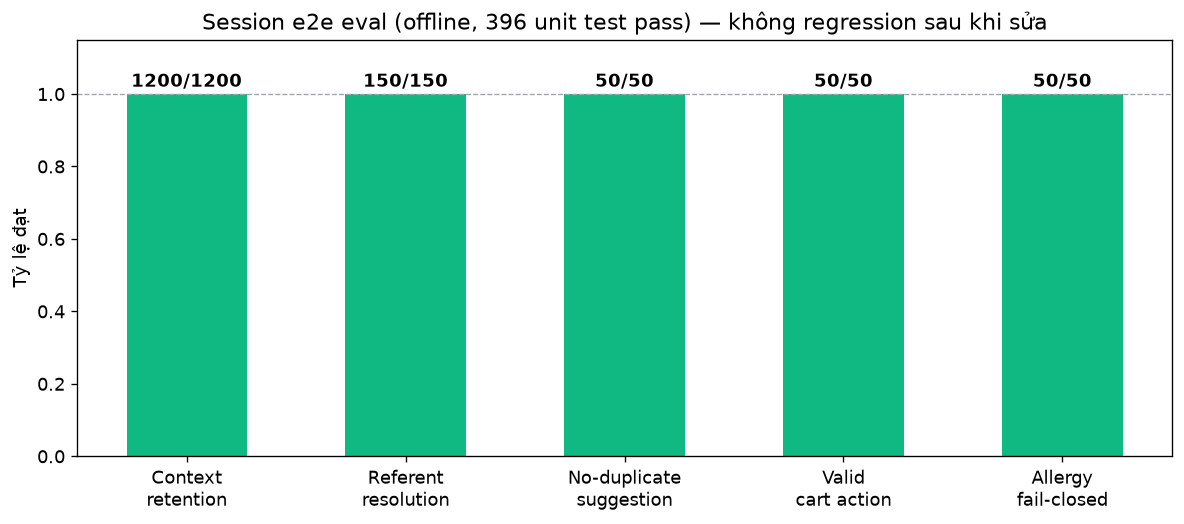

In [12]:
session_result = subprocess.run(
    [sys.executable, "evaluation/run_session_e2e_eval.py"],
    cwd=str(AI_ROOT), capture_output=True, text=True,
)
assert session_result.returncode == 0, session_result.stderr[-2000:]
session_eval_path = AI_ROOT / "evaluation" / "results" / "session_e2e_eval.json"
summary = json.loads(session_eval_path.read_text(encoding="utf-8"))["summary"]

keys = ("context_retention", "referent_resolution", "duplicate_free_extended",
        "valid_action_extended", "allergy_fail_closed")
labels = ["Context\nretention", "Referent\nresolution", "No-duplicate\nsuggestion",
          "Valid\ncart action", "Allergy\nfail-closed"]
rates = [summary[k]["numerator"] / summary[k]["denominator"] for k in keys]
ns = [f"{summary[k]['numerator']}/{summary[k]['denominator']}" for k in keys]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, rates, color=C_OK, width=0.55)
for bar, n in zip(bars, ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, n, ha="center", fontweight="bold")
ax.axhline(1.0, color="#9ca3af", linestyle="--", linewidth=0.8)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Tỷ lệ đạt")
ax.set_title(f"Session e2e eval (offline, {n_tests} unit test pass) — không regression sau khi sửa")
plt.tight_layout()
plt.show()

## 5.3 So sánh 3 pipeline profile — model chính thức hiện tại

### Bảng thuật ngữ (để đọc bảng dưới dễ hơn)

| Metric | Ý nghĩa |
|---|---|
| `strict_semantic_success` | % câu trả lời đúng ý định + đúng dữ liệu, chấm nghiêm ngặt |
| `context_accuracy` | % lượt hội thoại giữ đúng ngữ cảnh nhiều lượt (party size, dị ứng, đại từ tham chiếu...) |
| `p95_latency_ms` | Độ trễ tại percentile 95 — 5% chậm nhất vẫn nhanh hơn giá trị này |
| `mean_llm_calls` | Số lệnh gọi LLM trung bình mỗi lượt (profile `planner_state_v3` gọi 2 lần/lượt: semantic planner + generation) |

Ba profile (`llm_first_v1`, `evidence_first_v2`, `planner_state_v3`) đo bằng model chính thức hiện tại (`cx/gpt-5.6-luna-review`), sau khi Phần 1–3 đã sửa code dùng chung bởi cả ba profile:

In [13]:
probe = json.loads((AI_ROOT / "evaluation" / "results" / "pipeline_selection.luna_probe.json").read_text(encoding="utf-8"))

rows = []
for p in probe["profiles"]:
    m = p["metrics"]
    rows.append({
        "Profile": p["profile"],
        "strict_semantic_success": round(m["strict_semantic_success"], 4),
        "context_accuracy": round(m["context_accuracy"], 4),
        "p95_latency_ms": round(m["p95_latency_ms"], 1),
        "mean_llm_calls": round(m["mean_llm_calls"], 2),
        "safety_passed": m["safety_passed"],
        "unsupported_claims": m["unsupported_claims"],
    })
df_profiles = pd.DataFrame(rows)
print(f"Model: cx/gpt-5.6-luna-review  |  Winner theo tiêu chí hiện tại: {probe['winner']}")
display(df_profiles.style.hide(axis="index"))

Model: cx/gpt-5.6-luna-review  |  Winner theo tiêu chí hiện tại: planner_state_v3


Profile,strict_semantic_success,context_accuracy,p95_latency_ms,mean_llm_calls,safety_passed,unsupported_claims
llm_first_v1,0.862700,0.852900,18225.700000,2.120000,True,0
evidence_first_v2,0.938800,0.846900,20041.100000,2.080000,True,0
planner_state_v3,0.962300,0.915100,47502.400000,2.380000,True,0


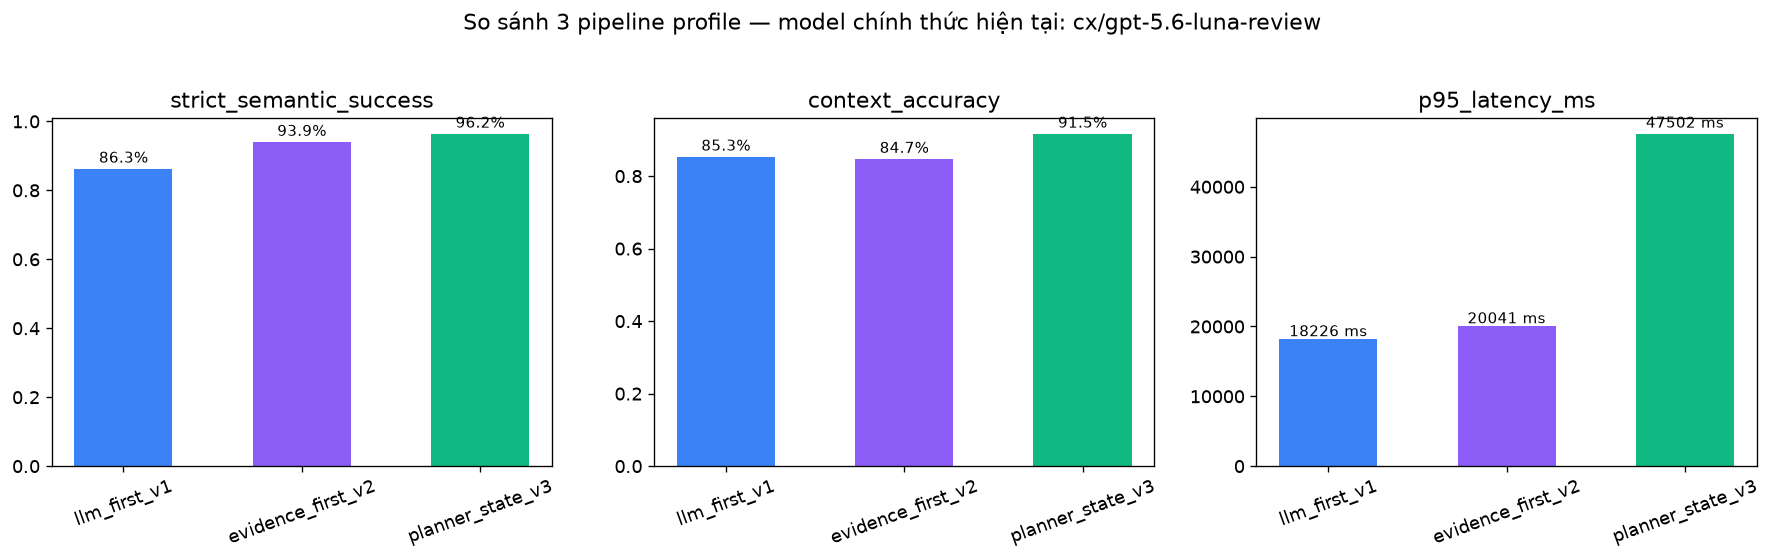

In [14]:
colors = {"llm_first_v1": C_INFO, "evidence_first_v2": C_PURPLE, "planner_state_v3": C_OK}
bar_colors = [colors[p] for p in df_profiles["Profile"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, fmt in zip(
    axes,
    ["strict_semantic_success", "context_accuracy", "p95_latency_ms"],
    ["{:.1%}", "{:.1%}", "{:.0f} ms"],
):
    bars = ax.bar(df_profiles["Profile"], df_profiles[metric], color=bar_colors, width=0.55)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, fmt.format(bar.get_height()),
                ha="center", fontsize=9)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("So sánh 3 pipeline profile — model chính thức hiện tại: cx/gpt-5.6-luna-review", y=1.03)
plt.tight_layout()
plt.show()

### Phân tích

- `context_accuracy` của `planner_state_v3` cách biệt rõ so với 2 profile còn lại — nhất quán với vai trò của `semantic_planner.py` (referent resolution, conversation frame) chỉ hoạt động ở profile này.
- `planner_state_v3` cũng dẫn đầu `strict_semantic_success`, nhưng `p95_latency_ms` cao hơn hẳn (gần gấp đôi) vì cần 2 lệnh gọi LLM/lượt.
- Mọi profile đều `safety_passed=True` và `unsupported_claims=0` — claim verifier (Phần 2) không để lọt claim nào kể cả sau khi đổi model và đổi prompt.

### Quyết định

Số liệu trên là baseline **hiện tại** của dự án — dùng làm điểm tham chiếu cho các lần đo tiếp theo. **Chưa** đủ căn cứ để đổi `AI_PIPELINE_PROFILE` mặc định sang `planner_state_v3` ngay: `context_accuracy` vượt trội là tín hiệu đáng cân nhắc, nhưng cần thêm dữ liệu SLO latency thực tế trước khi quyết định đánh đổi tốc độ phản hồi.

---
# Phần 6 — Kết luận

## Đã áp dụng vào repo hiện tại (uncommitted, chờ review)

1. **Cart-suggestion** không còn rỗng khi liệt kê món (`menu_presence_fast_path.py`, `_try_catalog_fast_path`).
2. Câu vừa hỏi danh mục vừa xin gợi ý không còn bị tắt nhầm gợi ý (`conversation_policy.py`).
3. Mâu thuẫn "diễn đạt lại vs. verify" được sửa ở tầng prompt (`prompts.py`), giữ nguyên độ nghiêm ngặt của `claim_verifier.py`.
4. `is_ambiguous` không còn bị keyword blacklist che giấu confidence thấp (`llm_intent_classifier.py`).
5. Model chính thức của dự án đổi sang `cx/gpt-5.6-luna-review`.

## Chưa quyết định — cần thêm dữ liệu trước khi chốt

- Có nên đổi `AI_PIPELINE_PROFILE` mặc định sang `planner_state_v3` hay không (Phần 5.3): context tốt hơn rõ rệt, nhưng cần đánh giá SLO latency thực tế trước.
- Ngưỡng `AMBIGUITY_CONFIDENCE_THRESHOLD` (0.35) có cần điều chỉnh sau khi tăng tần suất gọi LLM-assist hay không — cần đo latency/cost thật theo thời gian.

## Giới hạn của báo cáo này

- Baseline test suite **trước khi sửa** không đo được bằng công cụ trên máy làm việc (chưa cài Python khi bắt đầu phiên làm việc này).
- Compliance thật của model với hướng dẫn "claims[].text bám evidence" (Phần 2.3) chưa được đo bằng LLM thật trong notebook này — cần bổ sung vào lần chạy `run_golden_llm_eval.py`/`run_dual_llm_eval.py` tiếp theo.

---

*Báo cáo markdown song song (không cần môi trường Python để đọc): `docs/ai/AI_ASSISTANT_QUALITY_FIX_REPORT.md`.*